# Phase 1 — Exploratory Data Analysis
## AI-Based Content Moderation | Jigsaw Toxic Comment Dataset

---

**Objective:**  
Understand the structure, distribution, and characteristics of the Jigsaw Toxic Comment dataset before building any models.  
This notebook covers:
- Dataset loading and inspection
- Missing value analysis
- Label distribution across all toxicity categories
- Comment length analysis
- Top frequent words in toxic vs non-toxic comments
- Saving the cleaned dataset for downstream use

## 1. Setup & Imports

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
import string

warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

# ── Paths ────────────────────────────────────────────────────────────────────
RAW_DIR        = '../data/raw'
PROCESSED_DIR  = '../data/processed'
FIGURES_DIR    = '../reports/figures'

for d in [PROCESSED_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print('All directories ready.')

All directories ready.


---
## 2. Load Dataset

In [2]:
train_path = os.path.join(RAW_DIR, 'train.csv')
df = pd.read_csv(train_path)

print(f'Dataset loaded from: {train_path}')

Dataset loaded from: ../data/raw\train.csv


### 2.1 Shape & Column Names

In [3]:
print(f'Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumns:\n{list(df.columns)}')

Shape : 159,571 rows × 8 columns

Columns:
['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


### 2.2 Missing Values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0] if missing.sum() > 0 else 'No missing values found.')

No missing values found.


### 2.3 Sample Rows

In [5]:
df.head(5)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


---
## 3. Label Distribution

The dataset contains six toxicity labels:
- `toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, `identity_hate`

Each label is binary (0 = absent, 1 = present). A comment can carry multiple labels simultaneously.

In [6]:
LABEL_COLS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

label_counts = df[LABEL_COLS].sum().sort_values(ascending=False)
label_pct    = (label_counts / len(df) * 100).round(2)

label_summary = pd.DataFrame({
    'Count'      : label_counts,
    'Percentage' : label_pct
})
print(label_summary)

               Count  Percentage
toxic          15294        9.58
obscene         8449        5.29
insult          7877        4.94
severe_toxic    1595        1.00
identity_hate   1405        0.88
threat           478        0.30


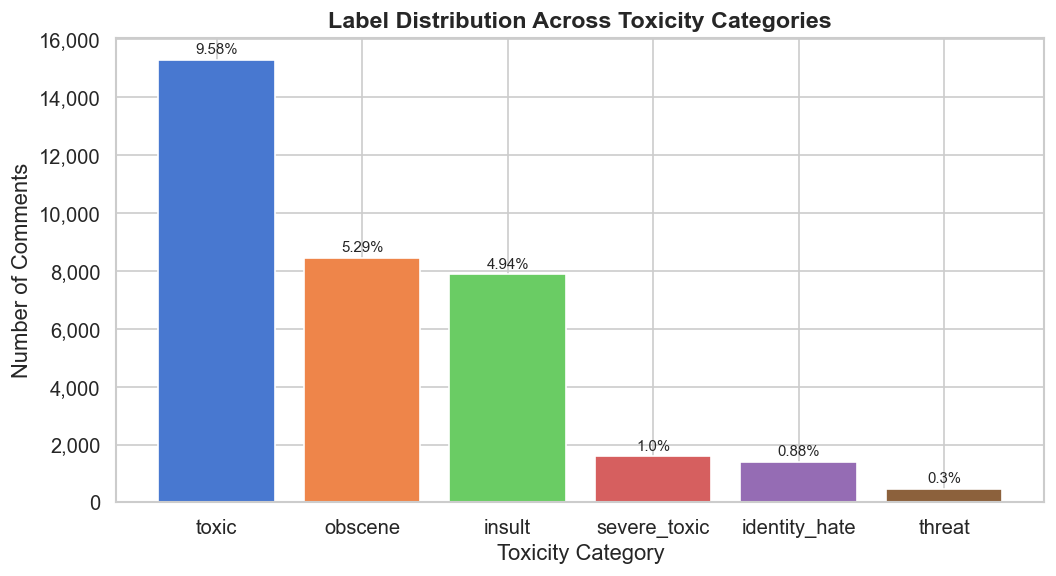

Saved → 01_label_distribution.png


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(label_counts.index, label_counts.values,
              color=sns.color_palette('muted', len(LABEL_COLS)), edgecolor='white')

for bar, pct in zip(bars, label_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 100,
            f'{pct}%', ha='center', va='bottom', fontsize=9)

ax.set_title('Label Distribution Across Toxicity Categories', fontsize=14, fontweight='bold')
ax.set_xlabel('Toxicity Category')
ax.set_ylabel('Number of Comments')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_label_distribution.png'))
plt.show()
print('Saved → 01_label_distribution.png')

**Observation:**  
`toxic` is by far the most common label, followed by `obscene` and `insult`. Labels like `threat` and `identity_hate` are rare, indicating a **highly imbalanced multi-label dataset**. This imbalance must be addressed during model training (e.g., class weights, oversampling, or threshold tuning).

---
## 4. Toxic vs Non-Toxic Comments

In [8]:
df['is_toxic'] = (df[LABEL_COLS].sum(axis=1) > 0).astype(int)

toxic_counts = df['is_toxic'].value_counts()
toxic_pct    = (toxic_counts / len(df) * 100).round(2)

print(f"Non-toxic : {toxic_counts[0]:,}  ({toxic_pct[0]}%)")
print(f"Toxic     : {toxic_counts[1]:,}  ({toxic_pct[1]}%)")

Non-toxic : 143,346  (89.83%)
Toxic     : 16,225  (10.17%)


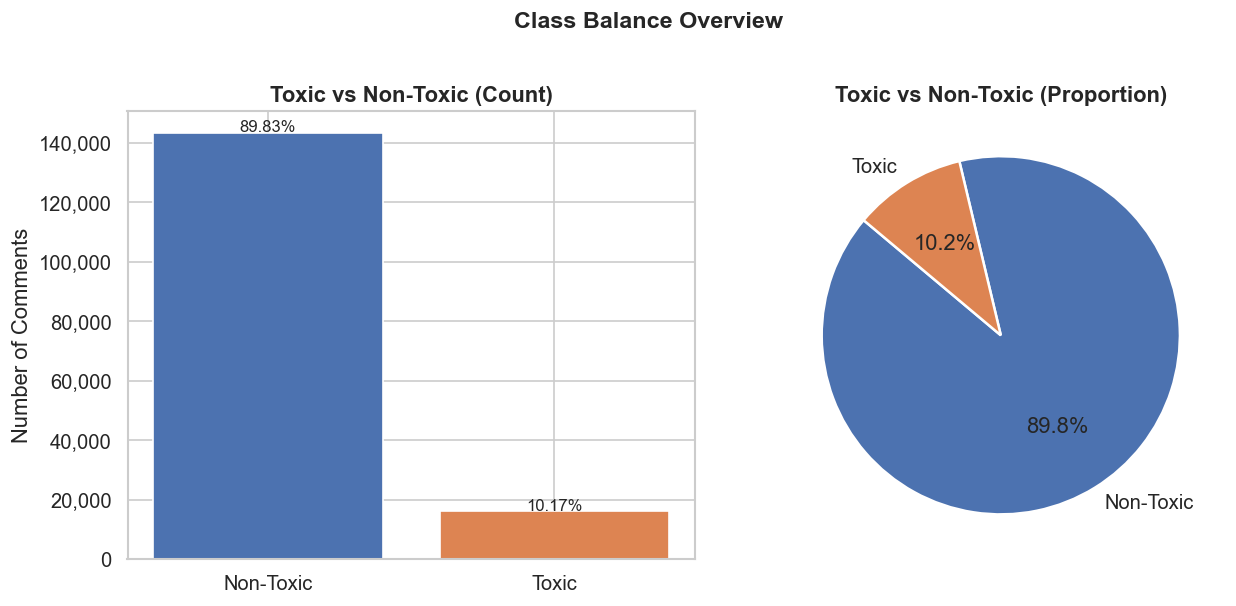

Saved → 02_toxic_vs_nontoxic.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Bar chart
colors = ['#4C72B0', '#DD8452']
axes[0].bar(['Non-Toxic', 'Toxic'], toxic_counts.values, color=colors, edgecolor='white')
for i, (v, p) in enumerate(zip(toxic_counts.values, toxic_pct.values)):
    axes[0].text(i, v + 200, f'{p}%', ha='center', fontsize=10)
axes[0].set_title('Toxic vs Non-Toxic (Count)', fontweight='bold')
axes[0].set_ylabel('Number of Comments')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
axes[1].pie(toxic_counts.values, labels=['Non-Toxic', 'Toxic'],
            autopct='%1.1f%%', colors=colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Toxic vs Non-Toxic (Proportion)', fontweight='bold')

plt.suptitle('Class Balance Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_toxic_vs_nontoxic.png'))
plt.show()
print('Saved → 02_toxic_vs_nontoxic.png')

**Observation:**  
The dataset is heavily skewed toward non-toxic comments (~90%). This class imbalance is a critical challenge — a naive classifier that always predicts "non-toxic" would achieve high accuracy but fail completely at detecting harmful content.

---
## 5. Comment Length Distribution

In [10]:
df['comment_length']     = df['comment_text'].astype(str).apply(len)
df['comment_word_count'] = df['comment_text'].astype(str).apply(lambda x: len(x.split()))

print('Character length stats:')
print(df['comment_length'].describe().round(1))
print('\nWord count stats:')
print(df['comment_word_count'].describe().round(1))

Character length stats:
count    159571.0
mean        394.1
std         590.7
min           6.0
25%          96.0
50%         205.0
75%         435.0
max        5000.0
Name: comment_length, dtype: float64

Word count stats:
count    159571.0
mean         67.3
std          99.2
min           1.0
25%          17.0
50%          36.0
75%          75.0
max        1411.0
Name: comment_word_count, dtype: float64


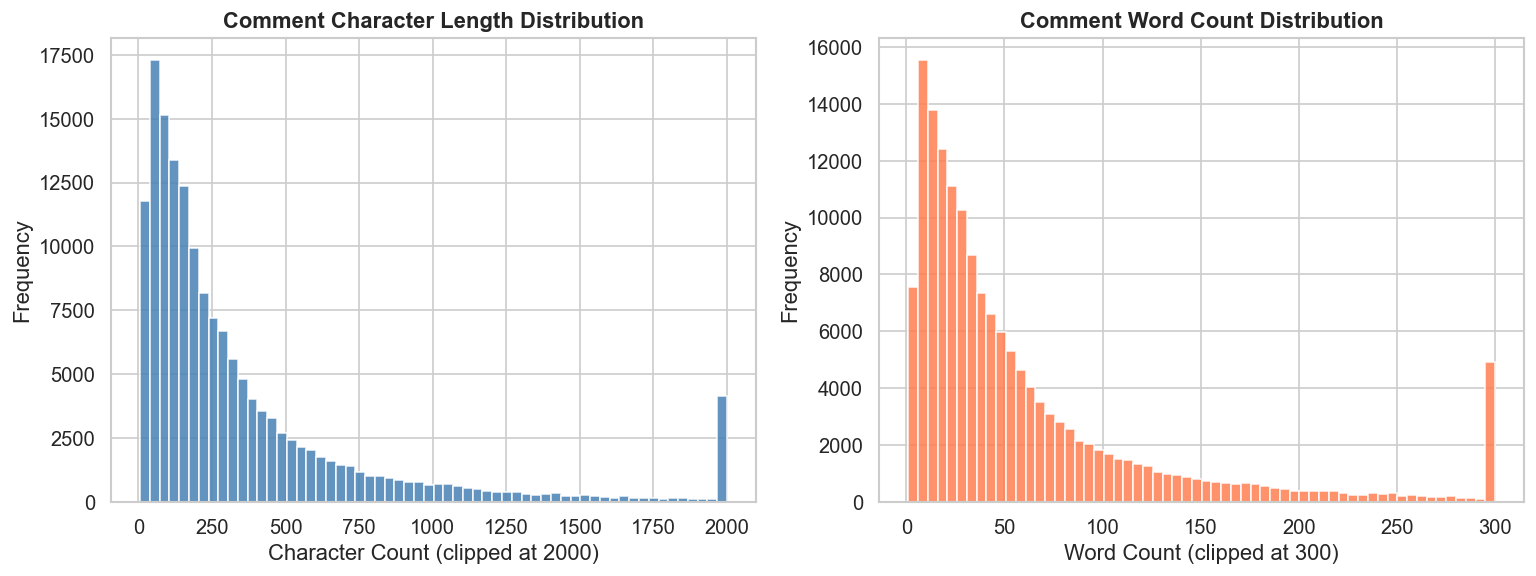

Saved → 03_comment_length_distribution.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Character length
axes[0].hist(df['comment_length'].clip(upper=2000), bins=60,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Comment Character Length Distribution', fontweight='bold')
axes[0].set_xlabel('Character Count (clipped at 2000)')
axes[0].set_ylabel('Frequency')

# Word count
axes[1].hist(df['comment_word_count'].clip(upper=300), bins=60,
             color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Comment Word Count Distribution', fontweight='bold')
axes[1].set_xlabel('Word Count (clipped at 300)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_comment_length_distribution.png'))
plt.show()
print('Saved → 03_comment_length_distribution.png')

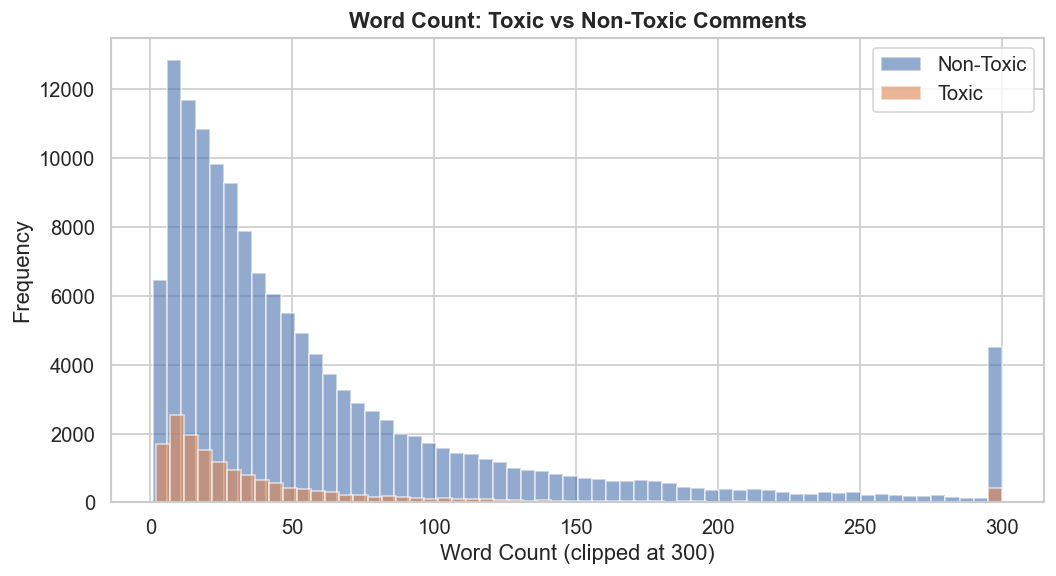

Saved → 04_length_toxic_vs_nontoxic.png


In [12]:
# Toxic vs Non-toxic length comparison
fig, ax = plt.subplots(figsize=(9, 5))
for label, color, name in [(0, '#4C72B0', 'Non-Toxic'), (1, '#DD8452', 'Toxic')]:
    subset = df[df['is_toxic'] == label]['comment_word_count'].clip(upper=300)
    ax.hist(subset, bins=60, alpha=0.6, color=color, label=name, edgecolor='white')

ax.set_title('Word Count: Toxic vs Non-Toxic Comments', fontweight='bold')
ax.set_xlabel('Word Count (clipped at 300)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_length_toxic_vs_nontoxic.png'))
plt.show()
print('Saved → 04_length_toxic_vs_nontoxic.png')

**Observation:**  
Most comments are short (under 100 words). Toxic comments tend to be slightly shorter on average, suggesting that harmful content is often expressed concisely. Long-tail distribution means we should consider truncation strategies when tokenizing for deep learning models.

---
## 6. Top Frequent Words

We tokenize comments, remove stopwords and punctuation, and count the most frequent words in toxic and non-toxic subsets.

In [13]:
# Basic English stopwords (no external library required)
STOPWORDS = {
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','yourselves','he','him','his','himself','she','her','hers',
    'herself','it','its','itself','they','them','their','theirs','themselves',
    'what','which','who','whom','this','that','these','those','am','is','are',
    'was','were','be','been','being','have','has','had','having','do','does',
    'did','doing','a','an','the','and','but','if','or','because','as','until',
    'while','of','at','by','for','with','about','against','between','into',
    'through','during','before','after','above','below','to','from','up','down',
    'in','out','on','off','over','under','again','further','then','once','here',
    'there','when','where','why','how','all','both','each','few','more','most',
    'other','some','such','no','nor','not','only','own','same','so','than',
    'too','very','s','t','can','will','just','don','should','now','d','ll',
    'm','o','re','ve','y','ain','aren','couldn','didn','doesn','hadn','hasn',
    'haven','isn','ma','mightn','mustn','needn','shan','shouldn','wasn',
    'weren','won','wouldn','also','would','could','get','got','like','one',
    'even','well','back','still','way','take','every','good','new','want',
    'us','go','know','think','see','come','make','time','said','say','people'
}

def tokenize(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = text.translate(str.maketrans('', '', string.punctuation + '0123456789'))
    tokens = text.split()
    return [t for t in tokens if t not in STOPWORDS and len(t) > 2]

toxic_words     = Counter()
nontoxic_words  = Counter()

for text in df[df['is_toxic'] == 1]['comment_text']:
    toxic_words.update(tokenize(text))

for text in df[df['is_toxic'] == 0]['comment_text']:
    nontoxic_words.update(tokenize(text))

TOP_N = 20
top_toxic    = pd.DataFrame(toxic_words.most_common(TOP_N),    columns=['word', 'count'])
top_nontoxic = pd.DataFrame(nontoxic_words.most_common(TOP_N), columns=['word', 'count'])

print('Top toxic words:')
print(top_toxic.head(10).to_string(index=False))

Top toxic words:
     word  count
     fuck   8675
     dont   3844
     shit   3657
wikipedia   3484
   nigger   3295
  fucking   3240
     suck   3050
      ass   2660
     hate   2636
     page   2344


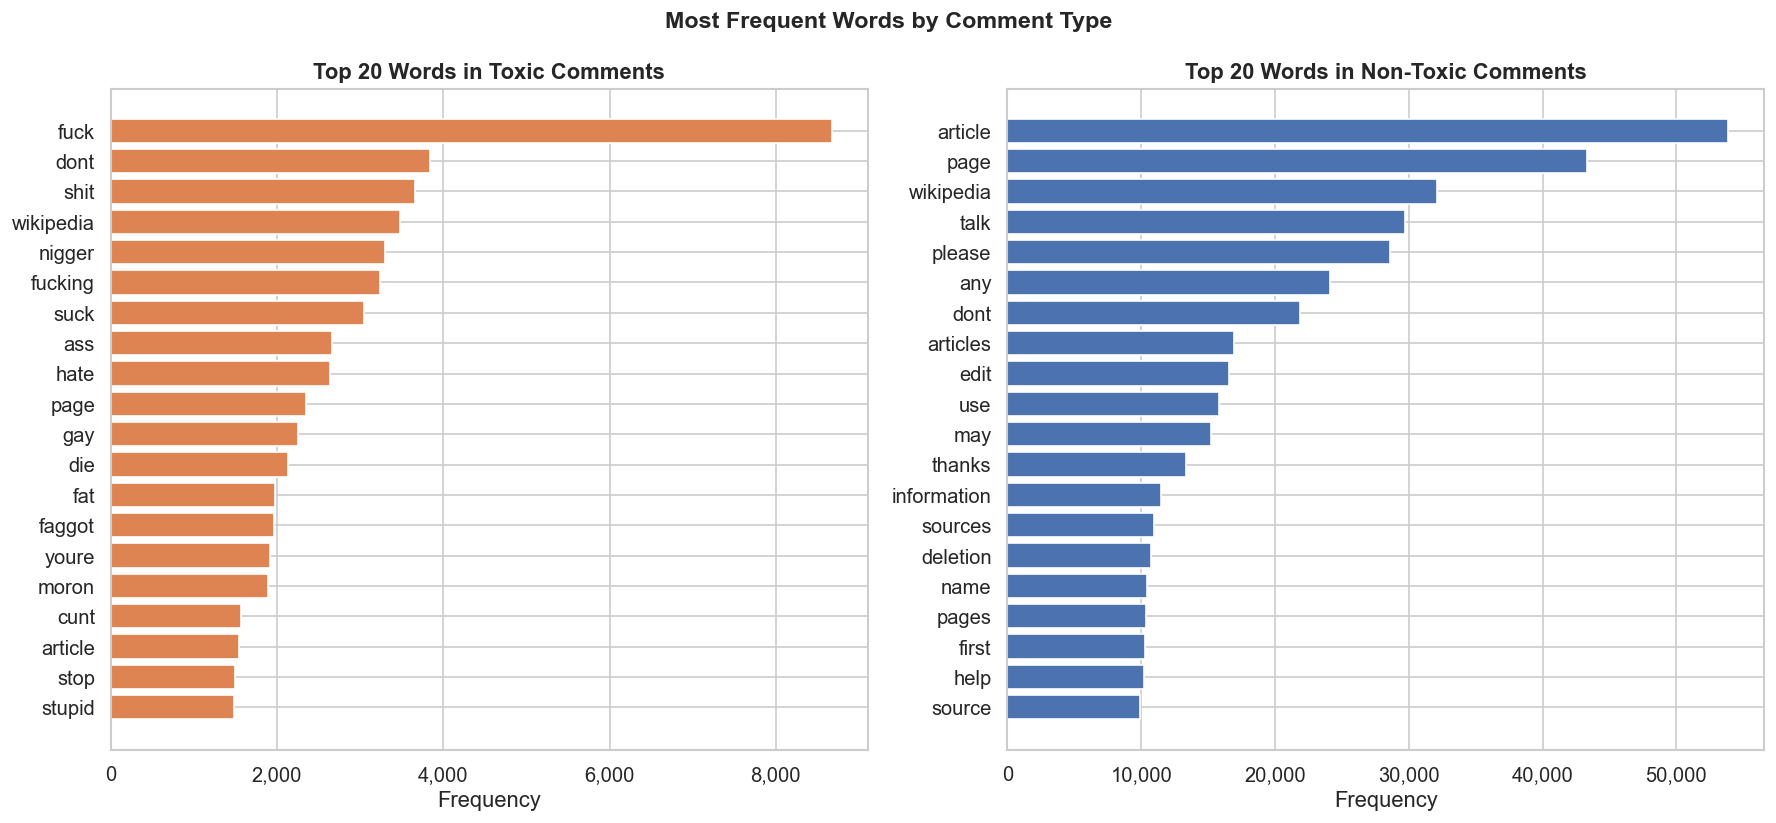

Saved → 05_top_words.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Toxic
axes[0].barh(top_toxic['word'][::-1], top_toxic['count'][::-1],
             color='#DD8452', edgecolor='white')
axes[0].set_title(f'Top {TOP_N} Words in Toxic Comments', fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Non-toxic
axes[1].barh(top_nontoxic['word'][::-1], top_nontoxic['count'][::-1],
             color='#4C72B0', edgecolor='white')
axes[1].set_title(f'Top {TOP_N} Words in Non-Toxic Comments', fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Most Frequent Words by Comment Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05_top_words.png'))
plt.show()
print('Saved → 05_top_words.png')

**Observation:**  
Toxic comments contain highly offensive and explicit vocabulary. Non-toxic comments revolve around neutral discussion topics (articles, Wikipedia, edits, etc.). This vocabulary gap is a strong signal for text classification models. However, relying solely on word frequency can lead to over-censorship — context matters.

---
## 7. Label Co-occurrence Heatmap

Understanding which toxicity labels tend to appear together helps in designing multi-label classification strategies.

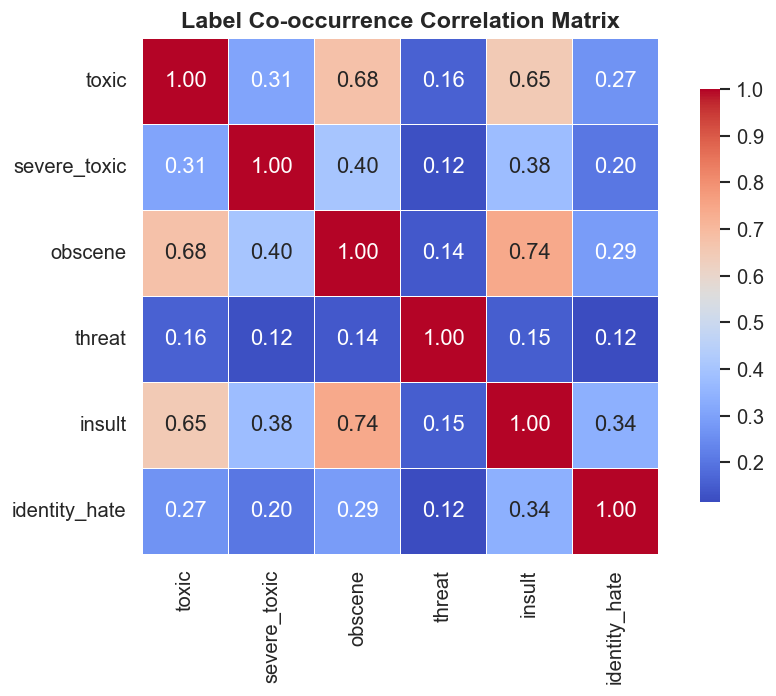

Saved → 06_label_correlation.png


In [15]:
corr_matrix = df[LABEL_COLS].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Label Co-occurrence Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06_label_correlation.png'))
plt.show()
print('Saved → 06_label_correlation.png')

**Observation:**  
`toxic` correlates strongly with `obscene` and `insult`, while `threat` and `identity_hate` are more independent. This suggests that some labels can be predicted jointly, while others may need dedicated classifiers.

---
## 8. Multi-label Count Distribution

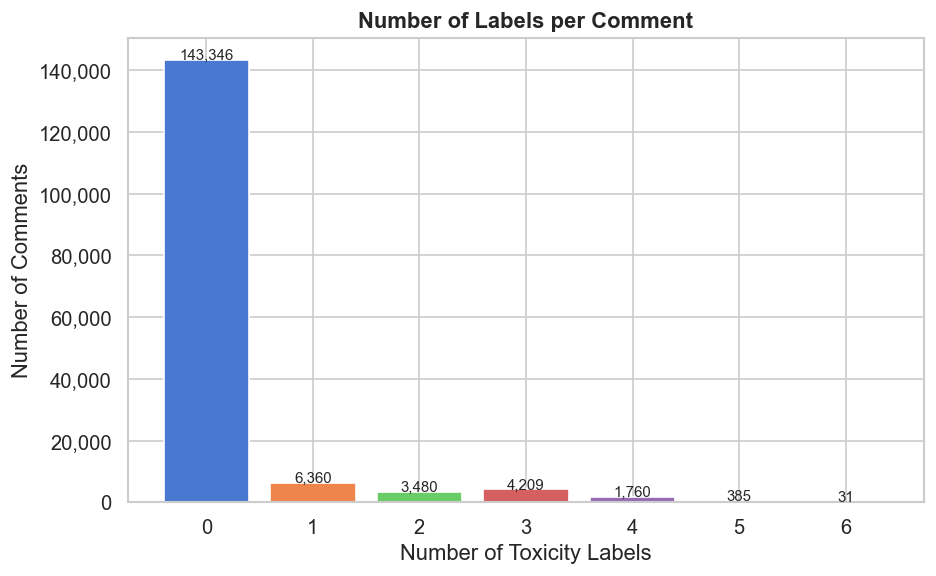

Saved → 07_multilabel_count.png


In [16]:
df['label_count'] = df[LABEL_COLS].sum(axis=1)
label_count_dist  = df['label_count'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(label_count_dist.index.astype(str), label_count_dist.values,
       color=sns.color_palette('muted', len(label_count_dist)), edgecolor='white')
ax.set_title('Number of Labels per Comment', fontweight='bold')
ax.set_xlabel('Number of Toxicity Labels')
ax.set_ylabel('Number of Comments')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for i, v in enumerate(label_count_dist.values):
    ax.text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '07_multilabel_count.png'))
plt.show()
print('Saved → 07_multilabel_count.png')

**Observation:**  
The vast majority of comments have 0 labels (non-toxic). Among toxic comments, most carry 1–2 labels. Very few comments carry all 6 labels simultaneously, confirming the sparse multi-label nature of the problem.

---
## 9. Save Cleaned Dataset

In [17]:
# Drop helper columns before saving (keep only original + engineered features)
df_clean = df.drop(columns=['is_toxic', 'label_count'], errors='ignore')

# Fill any remaining NaN in comment_text
df_clean['comment_text'] = df_clean['comment_text'].fillna('')

out_path = os.path.join(PROCESSED_DIR, 'train_cleaned.csv')
df_clean.to_csv(out_path, index=False)

print(f'Cleaned dataset saved → {out_path}')
print(f'Shape: {df_clean.shape}')
df_clean.head(3)

Cleaned dataset saved → ../data/processed\train_cleaned.csv
Shape: (159571, 10)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment_length,comment_word_count
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,264,43
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,112,17
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,233,42


---
## 10. Summary of Findings

| Insight | Detail |
|---|---|
| Dataset size | ~159,571 comments |
| Class imbalance | ~90% non-toxic, ~10% toxic |
| Most common label | `toxic` |
| Rarest label | `threat` / `identity_hate` |
| Avg comment length | ~67 words |
| Multi-label | Most toxic comments carry 1–2 labels |
| Strong correlations | `toxic` ↔ `obscene` ↔ `insult` |

### Next Steps (Phase 2)
- Text preprocessing pipeline (lowercasing, stopword removal, lemmatization)
- TF-IDF and word embedding baselines
- Handling class imbalance (class weights / oversampling)
- Baseline model training (Logistic Regression, Naive Bayes)